# 01 — EDA initial_dataset.csv

Цель ноутбука:
- посмотреть на исходный датасет `initial_dataset.csv`,
- проверить базовые распределения и аномалии,
- сформулировать правила чистки, которые реализованы в `src/data_prep/build_ml_dataset.py`.

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# чтобы можно было импортировать src.*
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_prep.build_ml_dataset import load_initial_dataset, build_ml_dataset
from src.utils.config import INITIAL_DATASET_PATH

In [2]:
print("PROJECT_ROOT:", PROJECT_ROOT)
print("INITIAL_DATASET_PATH:", INITIAL_DATASET_PATH)

df_raw = load_initial_dataset()
df_raw.shape

PROJECT_ROOT: /Users/rustamakhmedzianov/Documents/Projects/aero_nbo_uplift
INITIAL_DATASET_PATH: /Users/rustamakhmedzianov/Documents/Projects/aero_nbo_uplift/data/raw/initial_dataset.csv


(15312, 30)

In [3]:
df_raw.head()
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15312 entries, 0 to 15311
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   client_id                 15312 non-null  int64  
 1   treatment                 15312 non-null  int64  
 2   offer_id                  15312 non-null  int64  
 3   treatment_date            15312 non-null  object 
 4   offer_type                15312 non-null  object 
 5   offer_category            15312 non-null  object 
 6   cost                      15312 non-null  float64
 7   offer_AOV                 15312 non-null  float64
 8   channel                   15312 non-null  object 
 9   conversion                15312 non-null  int64  
 10  revenue_14d               15312 non-null  float64
 11  recency_days              15312 non-null  int64  
 12  frequency_90d             15312 non-null  int64  
 13  monetary_90d              15312 non-null  float64
 14  avg_or

In [4]:
num_cols = [
    "cost",
    "offer_AOV",
    "recency_days",
    "frequency_90d",
    "monetary_90d",
    "avg_order_value_lifetime",
    "total_orders_lifetime",
    "days_since_last_promo",
    "discounts_used_90d",
    "avg_discount_percent_90d",
    "email_open_rate_30d",
    "age",
    "revenue_14d",
]
df_raw[num_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
cost,15312.0,11.012108,216.985589,0.0,0.30,0.60,2.90,15.9845,63.0191,16725.05
offer_AOV,15312.0,68.064031,1432.521220,0.0,2.99,4.49,17.72,91.4600,358.5600,77183.60
recency_days,15312.0,91.424569,99.676271,0.0,0.00,2.00,50.00,311.0000,368.0000,373.00
frequency_90d,15312.0,41.190178,134.176884,0.0,0.00,0.00,16.00,145.0000,333.0000,5086.00
monetary_90d,15312.0,865.585649,4487.745382,0.0,0.00,0.00,292.34,2553.5005,7760.8400,168469.60
avg_order_value_lifetime,15312.0,68.064031,1432.521220,0.0,2.99,4.49,17.72,91.4600,358.5600,77183.60
total_orders_lifetime,15312.0,60.687239,134.652749,1.0,1.00,5.00,38.00,166.0000,341.8900,5121.00
days_since_last_promo,15312.0,29.426724,17.304478,0.0,0.00,2.00,29.00,56.0000,59.0000,59.00
discounts_used_90d,15312.0,2.889237,3.084978,0.0,0.00,0.00,2.00,9.0000,9.0000,9.00
avg_discount_percent_90d,15312.0,15.026985,5.745787,5.0,5.20,6.00,15.10,23.9000,24.8000,25.00


In [5]:
df_raw["treatment"].value_counts(dropna=False), df_raw["treatment"].value_counts(normalize=True)
df_raw["conversion"].value_counts(dropna=False), df_raw["conversion"].value_counts(normalize=True)

(conversion
 0    11659
 1     3653
 Name: count, dtype: int64,
 conversion
 0    0.761429
 1    0.238571
 Name: proportion, dtype: float64)

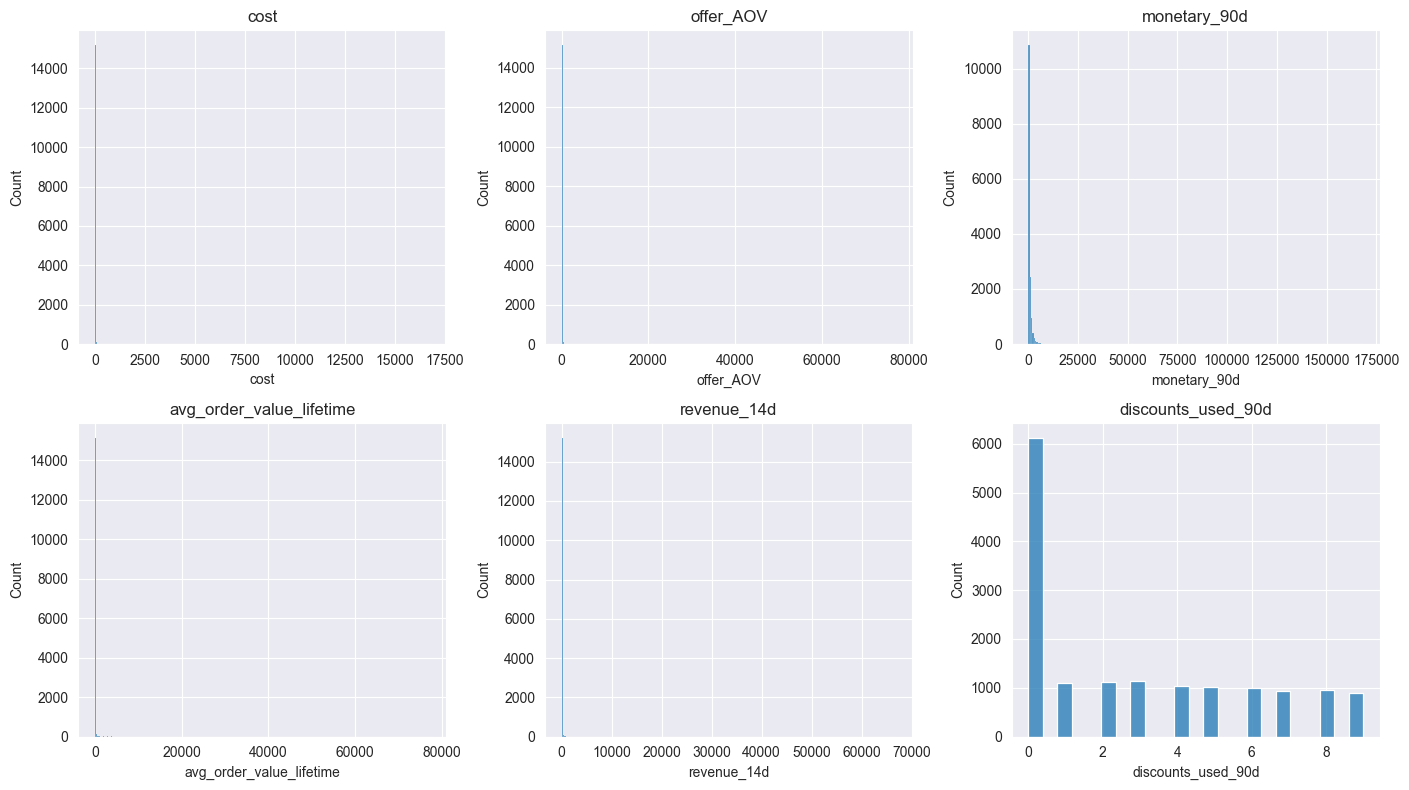

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, ["cost", "offer_AOV", "monetary_90d",
                          "avg_order_value_lifetime", "revenue_14d", "discounts_used_90d"]):
    sns.histplot(df_raw[col], kde=False, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [7]:
checks = {
    "cost < 0": (df_raw["cost"] < 0).sum(),
    "offer_AOV <= 0": (df_raw["offer_AOV"] <= 0).sum(),
    "monetary_90d < 0": (df_raw["monetary_90d"] < 0).sum(),
    "avg_order_value_lifetime <= 0": (df_raw["avg_order_value_lifetime"] <= 0).sum(),
    "revenue_14d < 0": (df_raw["revenue_14d"] < 0).sum(),
}
checks

{'cost < 0': np.int64(0),
 'offer_AOV <= 0': np.int64(5),
 'monetary_90d < 0': np.int64(0),
 'avg_order_value_lifetime <= 0': np.int64(5),
 'revenue_14d < 0': np.int64(0)}

In [8]:
df_ml_preview = build_ml_dataset(df_raw)
df_raw.shape, df_ml_preview.shape
df_ml_preview.head()

,client_id,treatment,offer_id,treatment_date,offer_type,offer_category,cost,offer_AOV,channel,conversion,...,age,gender,price_segment,treatment_dow,treatment_month,treatment_hour,time_morning,time_afternoon,time_evening,time_night
0,17850,1,0,2024-04-12,discount_10,category_0,2.09,18.15,app,0,...,37,F,budget,4,4,0,0,0,0,1
1,17850,0,2,2024-06-28,free_delivery,category_0,3.84,18.15,app,0,...,50,F,budget,4,6,0,0,0,0,1
2,17850,0,2,2024-04-02,free_delivery,category_0,1.44,18.15,web,0,...,39,F,budget,1,4,0,0,0,0,1
3,17850,0,1,2024-01-15,discount_20,category_0,5.21,18.15,web,0,...,22,F,budget,0,1,0,0,0,0,1
4,13047,0,1,2024-04-16,discount_20,category_8,2.00,18.82,web,0,...,60,M,budget,1,4,0,0,0,0,1


## Выводы по EDA

1. `treatment` и `conversion` — бинарные признаки без (или с малым числом) шумных значений.
2. Значения `cost`, `offer_AOV`, `monetary_90d`, `avg_order_value_lifetime`, `revenue_14d`:
   - отрицательных значений: 0 / немного,
   - нулевые `offer_AOV` нужно отфильтровать.
3. Распределения `monetary_90d` и `revenue_14d` имеют тяжёлые хвосты → при необходимости можно клиповать по 1–99 перцентилям.
4. Столбец `other` – служебный, в моделях не используется.
5. `revenue_14d` — утечка таргета для задач клик-аплифта, удаляем в `build_ml_dataset.py`.

Чистка и добавление временных фич уже реализованы в `build_ml_dataset.py` и дают
`ml_training_dataset.csv`, который используется в дальнейших шагах.